<h1 style='text-align:center;color:green;font-weight:bold'>Netflix Trends & Insights</h1>

## 1. Importing Essential Python Libraries


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Loading And Overview Data

In [2]:
df = pd.read_csv(r"C:\Users\Administrator\Downloads\archive (6)\netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 2. Cleaning And Preprocessing Data

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['director'] = df['director'].fillna('Not Specified')
df['cast'] = df['cast'].fillna('Not Specified')
df['country'] = df['country'].fillna('Not Specified')

In [9]:
df.dropna(inplace=True)

In [10]:
df.shape

(8790, 12)

In [11]:
df.duplicated().sum()

0

### Feature Engineering

In [14]:
df['date_added'] = df['date_added'].apply(lambda x: x.strip())

In [15]:
df['year'] = df['date_added'].apply(lambda x: x.split(",")[1])
df["month"] = df['date_added'].apply(lambda x: x.split(" ")[0])
df["day"] = df['date_added'].apply(lambda x: x.split(" ")[1])
df["day"] = df["day"].apply(lambda x: x.replace(",",""))

## 3. Exploratory Data Analysis (EDA)

##### Q1: What type of content is more common — Movies or TV Shows?

In [22]:
df['type'].value_counts().reset_index()

,type,count
0,Movie,6126
1,TV Show,2664


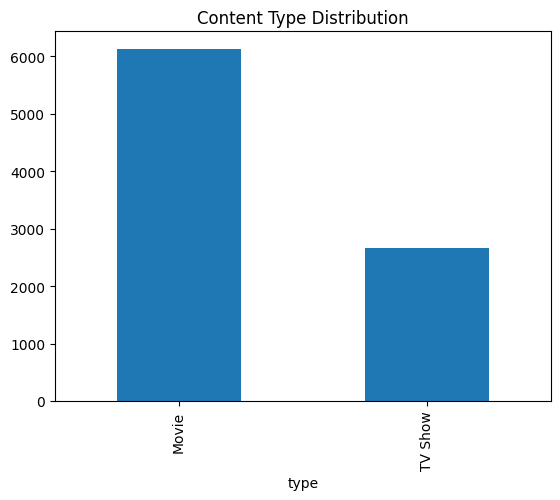

In [25]:
df['type'].value_counts().plot(kind='bar', x='type',y='No Of Movies',title='Content Type Distribution')
plt.show()

######  Q2: What are the top countries producing Netflix content?

In [29]:
df['country'].value_counts().reset_index().head(5).sort_values(by='count', ascending=False)

,country,count
0,United States,2809
1,India,972
2,Not Specified,829
3,United Kingdom,418
4,Japan,243


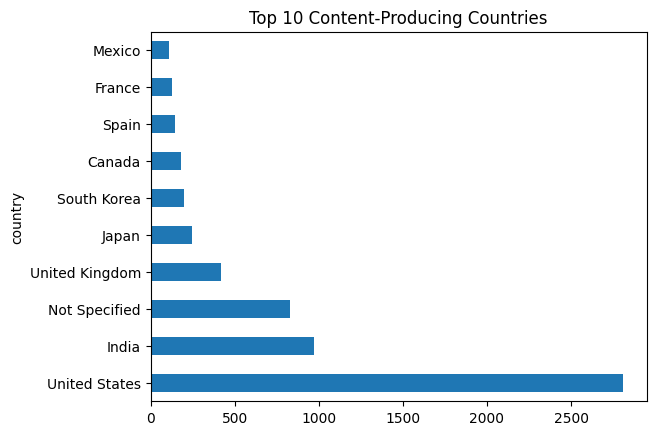

In [30]:
df['country'].value_counts().head(10).plot(kind='barh', title='Top 10 Content-Producing Countries')
plt.show()

###### Q3: How has content been added over the years?

In [33]:
df['year'].value_counts().sort_index().reset_index()

,year,count
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,426
9,2017,1185


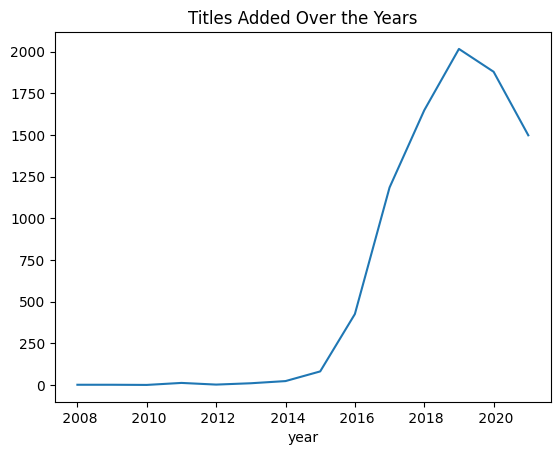

In [31]:
df['year'].value_counts().sort_index().plot(kind='line', title='Titles Added Over the Years')
plt.show()

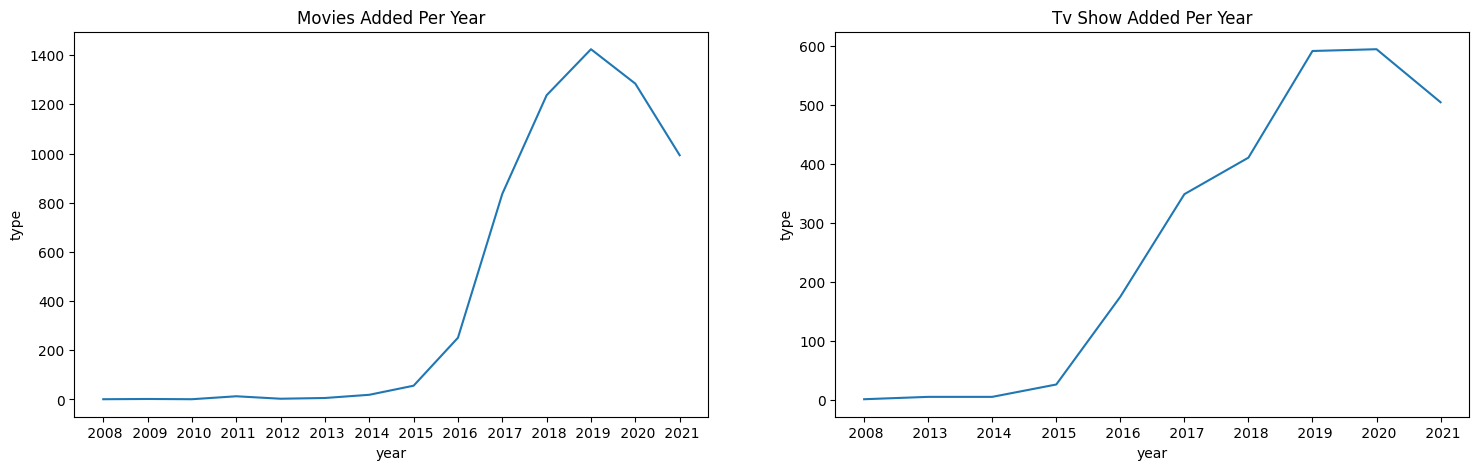

In [60]:
#movies count each year
seasonal_movies = df[df['type'] == 'Movie'].groupby('year')['type'].count().reset_index()
#tv show count each year
seasonal_tv_show = df[df['type'] == 'TV Show'].groupby('year')['type'].count().reset_index()

fig, ax = plt.subplots(1,2,figsize=(18,5))
sns.lineplot(data= seasonal_movies, x='year',y='type', ax=ax[0])
ax[0].set_title('Movies Added Per Year')

sns.lineplot(data= seasonal_tv_show, x='year',y='type', ax=ax[1])
ax[1].set_title('Tv Show Added Per Year')
plt.show()

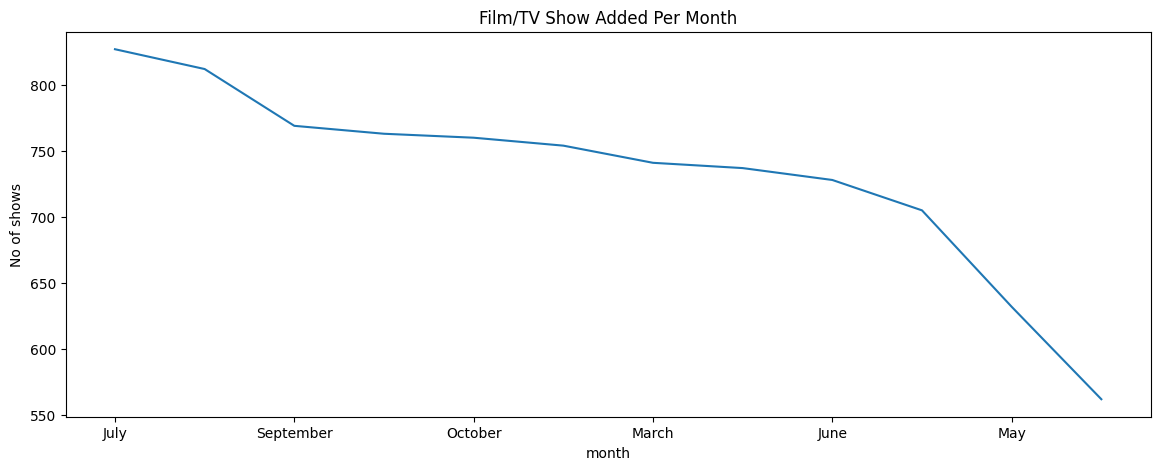

In [34]:
plt.figure(figsize=(14,5))
df.month.value_counts().plot(kind="line", title ="Film/TV Show Added Per Month")
plt.ylabel("No of shows")
plt.show()

######  Q4: who Are Most Content Created directors?

In [66]:
df['director'].value_counts().sort_values(ascending=False).head(5)

director
Not Specified             2621
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Name: count, dtype: int64

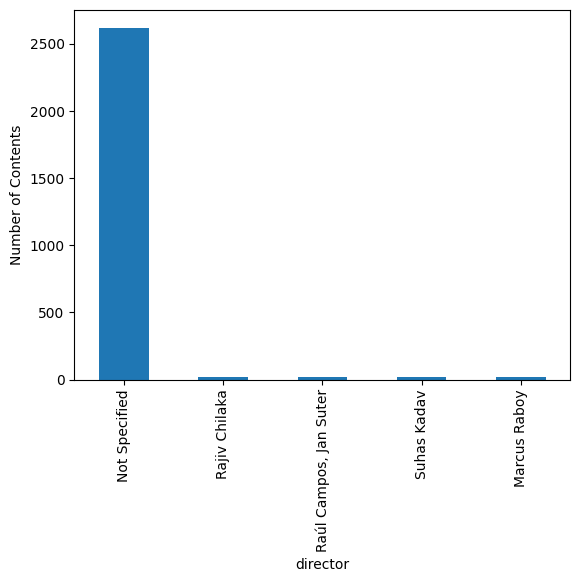

In [69]:
df['director'].value_counts().sort_values(ascending=False).head(5).plot(kind='bar')
plt.ylabel('Number of Contents')
plt.show()

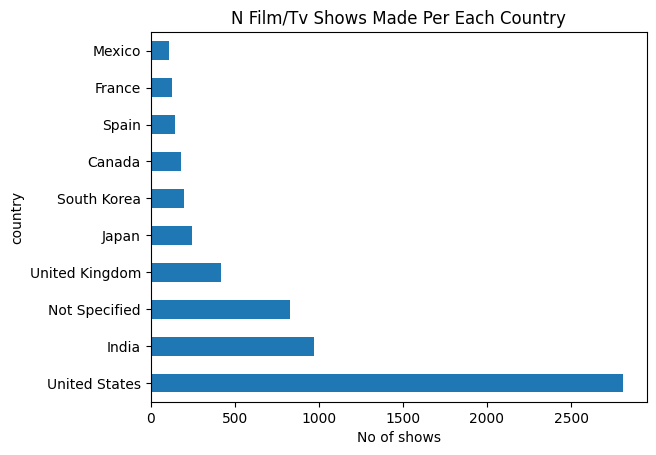

In [439]:
df["country"].value_counts().head(10).plot(kind="barh",title="N Film/Tv Shows Made Per Each Country")
plt.xlabel("No of shows")
plt.show()

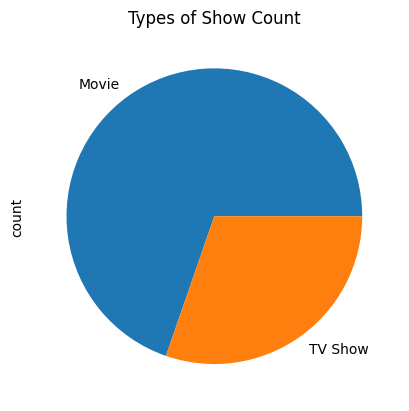

In [412]:
df.type.value_counts().plot(kind="pie",title="Types of Show Count")
plt.show()

In [413]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'month', 'day', 'year'],
      dtype='object')

In [414]:
movies = df[df["type"] == "Movie"].copy()
tv_shows = df[df["type"] == "TV Show"].copy()

In [415]:
# Clean duration for movies
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(int)

# Clean duration for TV shows
tv_shows['seasons'] = tv_shows['duration'].str.extract(r'(\d+)').astype(int)

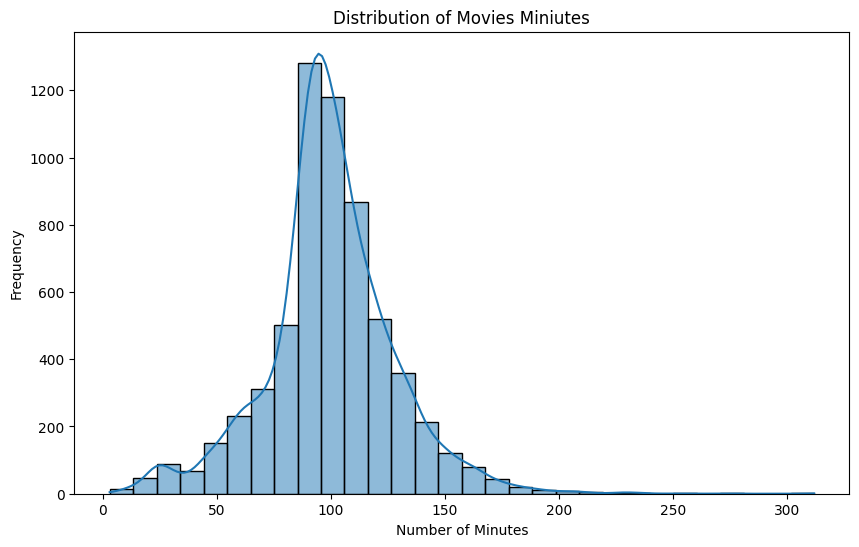

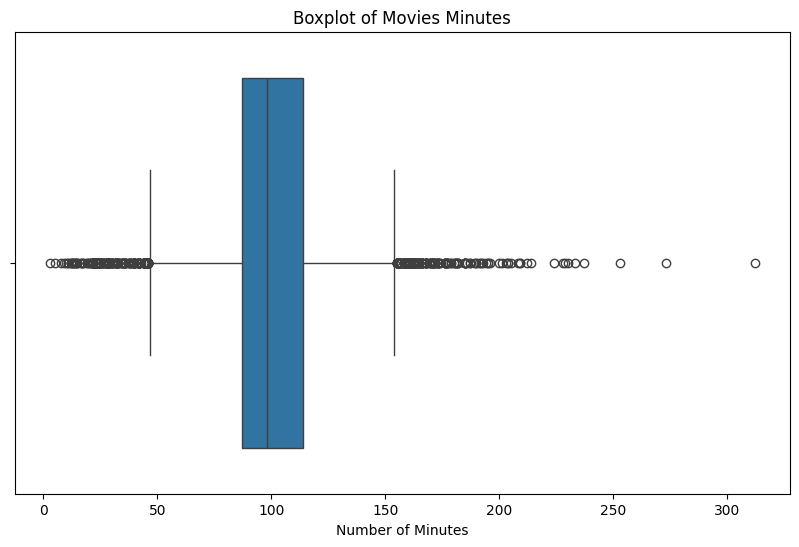

In [416]:
plt.figure(figsize=(10, 6))
sns.histplot(movies['duration_min'], bins=30, kde=True)
plt.title('Distribution of Movies Miniutes')
plt.xlabel('Number of Minutes')
plt.ylabel('Frequency')
plt.show()

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=movies['duration_min'])
plt.title('Boxplot of Movies Minutes')
plt.xlabel('Number of Minutes')
plt.show()

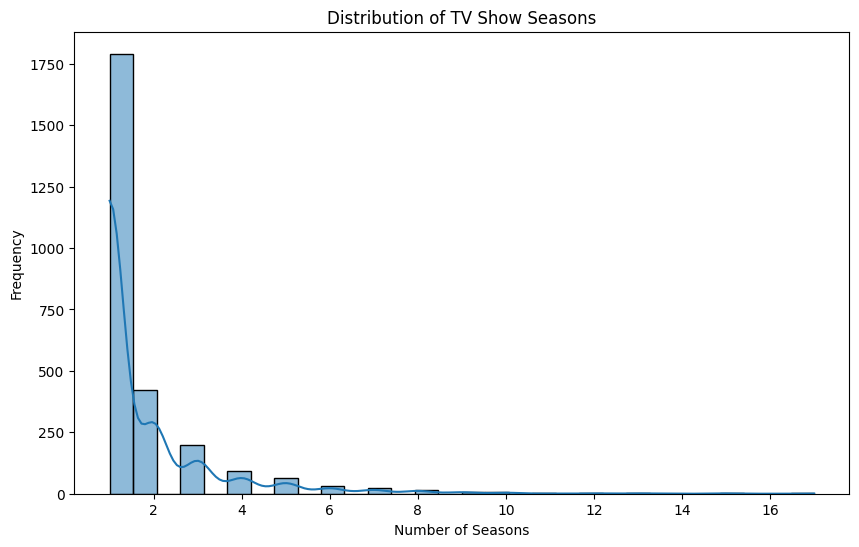

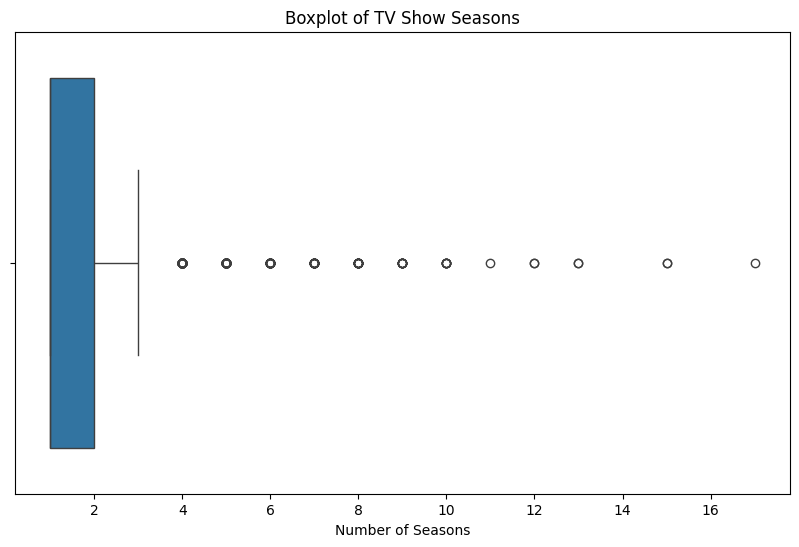

In [417]:
plt.figure(figsize=(10, 6))
sns.histplot(tv_shows['seasons'], bins=30, kde=True)
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Frequency')
plt.show()

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=tv_shows['seasons'])
plt.title('Boxplot of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.show()

In [418]:
# # Define a function to categorize seasons
# def categorize_seasons(seasons):
#     if seasons == 1:
#         return '1 Season'
#     elif 2 <= seasons <= 3:
#         return '2-3 Seasons'
#     elif 4 <= seasons <= 5:
#         return '4-5 Seasons'
#     elif 6 <= seasons <= 10:
#         return '6-10 Seasons'
#     else:
#         return '10+ Seasons'

# # Apply the function to the 'seasons' column
# tv_shows['seasons_category'] = tv_shows['seasons'].apply(categorize_seasons)

In [419]:
# Define bins and labels
bins = [0, 1, 3, 5, 10, float('inf')]
labels = ['1 Season', '2-3 Seasons', '4-5 Seasons', '6-10 Seasons', '10+ Seasons']

# Categorize using pd.cut
tv_shows['seasons_category'] = pd.cut(tv_shows['seasons'], bins=bins, labels=labels, right=False)

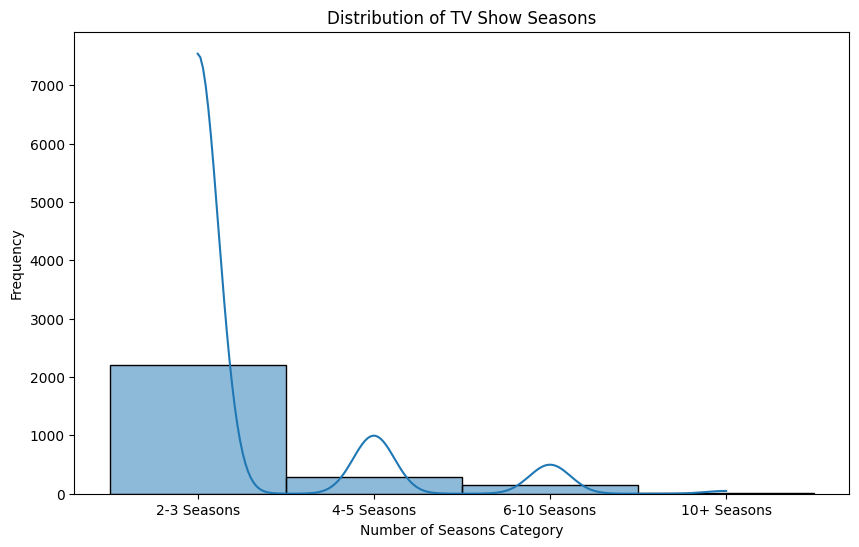

In [420]:
plt.figure(figsize=(10, 6))
sns.histplot(tv_shows['seasons_category'], bins=30, kde=True)
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons Category')
plt.ylabel('Frequency')
plt.show()

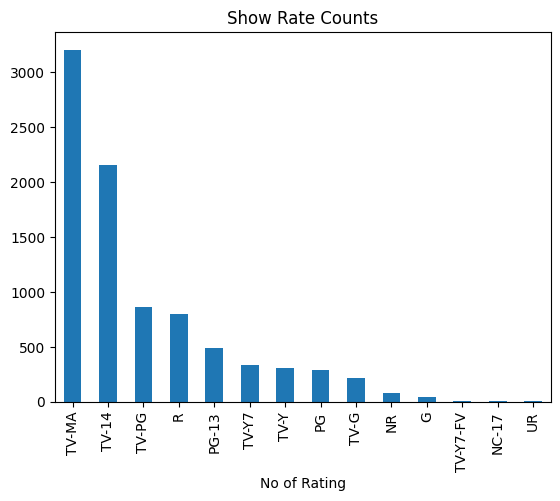

In [437]:
df['rating'].value_counts().plot(kind='bar',title='Show Rate Counts')
plt.xlabel("No of Rating")
plt.show()

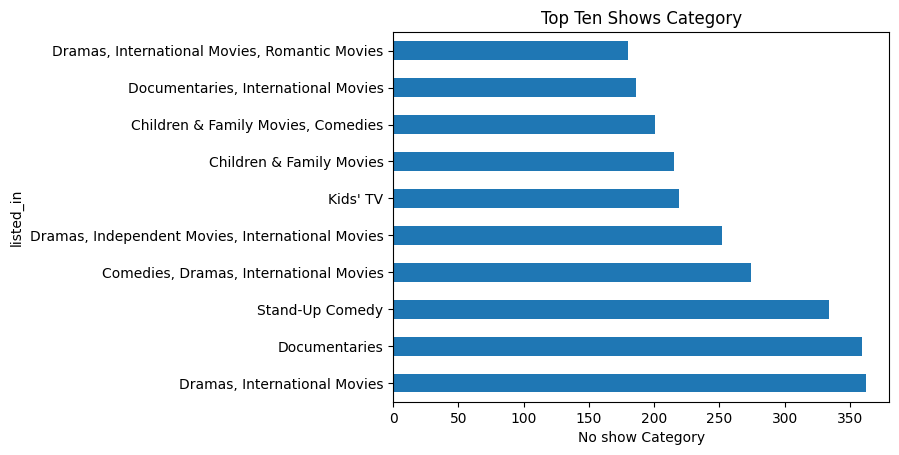

In [436]:
df['listed_in'].value_counts().head(10).plot(kind='barh',title="Top Ten Shows Category")
plt.xlabel("No show Category")
plt.show()

In [421]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,day,year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",September,25,2021
1,s2,TV Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",September,24,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",Not Specified,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",September,24,2021
3,s4,TV Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",September,24,2021
4,s5,TV Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",September,24,2021
